# Taller Práctico 3 — Detección de trayectoria de asteroides (Colab)

**Antes de ejecutar:** menú **Entorno de ejecución → Cambiar tipo de entorno de ejecución → GPU** (T4 u otra NVIDIA). Sin GPU, la parte CUDA no funcionará; la versión CPU sí.

Este cuaderno implementa el pipeline del PDF: filtro 3×3, diferencia temporal, umbral, apertura morfológica (erosión + dilatación), centroide, veredicto y gráfica.

In [1]:
# Instalación (Colab ya trae numpy/matplotlib/cv2 a veces; forzamos lo necesario)
!pip install -q opencv-python-headless "numba>=0.58"

se encarga de verificar si hay una GPU disponible para usar con Numba (CUDA) en el sistema.

In [2]:
import time
import numpy as np
import cv2
import matplotlib.pyplot as plt


from numba import cuda

def gpu_disponible() -> bool:
    try:
        cuda.select_device(0)
        return cuda.is_available()
    except Exception:
        return False

print("Numba CUDA disponible:", cuda.is_available())
print("GPU usable:", gpu_disponible())

Numba CUDA disponible: True
GPU usable: True


## Configuración del experimento

- `UMBRAL`: píxeles de la imagen de diferencia **menores** que este valor → 0; si el asteroide no aparece, baja el umbral; si hay mucho ruido, súbelo.
- Elige **una** fuente de vídeo en la siguiente celda.

In [3]:
UMBRAL = 30
MAX_FRAMES = 0  # 0 = procesar todo el vídeo

# Ruta del vídeo en Colab (se completará según la opción que elijas abajo)
VIDEO_PATH = "/content/video_prueba.mp4"

### Opción A — Vídeo sintético (sin descargar nada)
Ejecuta la celda siguiente para generar un `.mp4` con un punto en movimiento.

In [4]:
def generar_video_sintetico(ruta: str, frames: int = 120, w: int = 640, h: int = 480, fps: int = 24) -> None:
    fourcc = cv2.VideoWriter_fourcc(*"mp4v")
    vw = cv2.VideoWriter(ruta, fourcc, float(fps), (w, h))
    rng = np.random.default_rng(42)
    x0, y0 = w * 0.15, h * 0.45
    x1, y1 = w * 0.85, h * 0.55
    for t in range(frames):
        alpha = t / max(frames - 1, 1)
        cx = int(x0 + (x1 - x0) * alpha)
        cy = int(y0 + (y1 - y0) * alpha)
        frame = np.zeros((h, w, 3), dtype=np.uint8)
        noise = rng.integers(0, 256, size=(h, w), dtype=np.uint8)
        bright = noise > 250
        gray = np.where(bright, noise, 0).astype(np.uint8)
        frame[:, :, 0] = gray
        frame[:, :, 1] = gray
        frame[:, :, 2] = gray
        for dy in range(-2, 3):
            for dx in range(-2, 3):
                yy, xx = cy + dy, cx + dx
                if 0 <= yy < h and 0 <= xx < w:
                    frame[yy, xx] = (240, 245, 255)
        mask = rng.random((h, w)) < 0.002
        frame[mask] = (255, 255, 255)
        vw.write(frame)
    vw.release()
    print("Guardado:", ruta)

generar_video_sintetico(VIDEO_PATH)


Guardado: /content/video_prueba.mp4


### Opción B — Subir tu `.mp4` desde el PC
Si usas esta opción, **no** hace falta la opción A. Descomenta y ejecuta:

In [5]:
# from google.colab import files
# uploaded = files.upload()  # elige tu .mp4
# assert len(uploaded) == 1
# VIDEO_PATH = "/content/" + list(uploaded.keys())[0]
# print("VIDEO_PATH =", VIDEO_PATH)


### Opción C — Vídeo en Google Drive
Monta Drive y pon la ruta completa al archivo del taller.

In [6]:
# from google.colab import drive
# drive.mount("/content/drive")
# VIDEO_PATH = "/content/drive/MyDrive/ruta/a/tu_video.mp4"


## Pipeline CPU (NumPy)

proceso completo de detección de movimiento en imágenes en escala de grises, usando operaciones básicas de procesamiento digital.

In [5]:
def box_mean_3x3(gray: np.ndarray) -> np.ndarray:
    g = gray.astype(np.float32)
    padded = np.pad(g, 1, mode="edge")
    out = (
        padded[0:-2, 0:-2] + padded[0:-2, 1:-1] + padded[0:-2, 2:]
        + padded[1:-1, 0:-2] + padded[1:-1, 1:-1] + padded[1:-1, 2:]
        + padded[2:, 0:-2] + padded[2:, 1:-1] + padded[2:, 2:]
    ) / 9.0
    return np.clip(np.round(out), 0, 255).astype(np.uint8)


def temporal_diff_abs_smooth(curr_smooth: np.ndarray, prev_smooth: np.ndarray) -> np.ndarray:
    d = curr_smooth.astype(np.int16) - prev_smooth.astype(np.int16)
    return np.abs(d).astype(np.uint8)


def threshold_binary(diff: np.ndarray, thresh: int) -> np.ndarray:
    return np.where(diff < thresh, np.uint8(0), np.uint8(255)).astype(np.uint8)


def erode_3x3(binary: np.ndarray) -> np.ndarray:
    b = binary.astype(np.float32)
    padded = np.pad(b, 1, mode="edge")
    stacks = np.stack(
        [
            padded[0:-2, 0:-2], padded[0:-2, 1:-1], padded[0:-2, 2:],
            padded[1:-1, 0:-2], padded[1:-1, 1:-1], padded[1:-1, 2:],
            padded[2:, 0:-2], padded[2:, 1:-1], padded[2:, 2:],
        ],
        axis=-1,
    )
    m = stacks.min(axis=-1)
    return np.where(m >= 128, np.uint8(255), np.uint8(0)).astype(np.uint8)


def dilate_3x3(binary: np.ndarray) -> np.ndarray:
    b = binary.astype(np.float32)
    padded = np.pad(b, 1, mode="edge")
    stacks = np.stack(
        [
            padded[0:-2, 0:-2], padded[0:-2, 1:-1], padded[0:-2, 2:],
            padded[1:-1, 0:-2], padded[1:-1, 1:-1], padded[1:-1, 2:],
            padded[2:, 0:-2], padded[2:, 1:-1], padded[2:, 2:],
        ],
        axis=-1,
    )
    m = stacks.max(axis=-1)
    return np.where(m >= 128, np.uint8(255), np.uint8(0)).astype(np.uint8)


def opening_3x3(binary: np.ndarray) -> np.ndarray:
    return dilate_3x3(erode_3x3(binary))


def centroid_white(mask: np.ndarray):
    ys, xs = np.where(mask >= 128)
    if xs.size == 0:
        return None
    return float(xs.mean()), float(ys.mean())


def process_frame_pair_cpu(curr_gray: np.ndarray, prev_smooth: np.ndarray, thresh: int):
    curr_s = box_mean_3x3(curr_gray)
    diff = temporal_diff_abs_smooth(curr_s, prev_smooth)
    bin_img = threshold_binary(diff, thresh)
    mask = opening_3x3(bin_img)
    c = centroid_white(mask)
    return curr_s, mask, c


procesa un video completo en CPU para detectar movimiento y registrar la trayectoria de un objeto.

In [6]:
def ejecutar_cpu(video_path: str, umbral: int, max_frames: int = 0):
    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        raise RuntimeError(f"No se pudo abrir: {video_path}")
    ret, first = cap.read()
    if not ret:
        cap.release()
        raise RuntimeError("Vídeo vacío")

    fondo = cv2.cvtColor(first, cv2.COLOR_BGR2GRAY)
    gray0 = fondo.copy()
    smooth_prev = box_mean_3x3(gray0)
    trayectoria = []
    frame_idx = 1
    t0 = time.perf_counter()

    while True:
        ret, bgr = cap.read()
        if not ret:
            break
        if max_frames and frame_idx >= max_frames:
            break
        gray = cv2.cvtColor(bgr, cv2.COLOR_BGR2GRAY)
        smooth_prev, _mask, centroide = process_frame_pair_cpu(gray, smooth_prev, umbral)
        if centroide is not None:
            trayectoria.append(centroide)
        frame_idx += 1

    elapsed = time.perf_counter() - t0
    cap.release()
    return trayectoria, fondo, elapsed, frame_idx


## Kernels CUDA (Numba) y pipeline híbrido

In [7]:
@cuda.jit
def k_rgb_to_gray_bgr(src, dst, h, w):
    y, x = cuda.grid(2)
    if y < h and x < w:
        b = np.float32(src[y, x, 0])
        g = np.float32(src[y, x, 1])
        r = np.float32(src[y, x, 2])
        gray = 0.299 * r + 0.587 * g + 0.114 * b
        dst[y, x] = np.uint8(gray + 0.5)


@cuda.jit
def k_box_mean_3x3_u8(src, dst, h, w):
    y, x = cuda.grid(2)
    if y < h and x < w:
        s = 0
        for dy in (-1, 0, 1):
            for dx in (-1, 0, 1):
                yy = min(max(y + dy, 0), h - 1)
                xx = min(max(x + dx, 0), w - 1)
                s += int(src[yy, xx])
        dst[y, x] = np.uint8(s // 9)


@cuda.jit
def k_abs_diff_u8(a, b, d, h, w):
    y, x = cuda.grid(2)
    if y < h and x < w:
        va = int(a[y, x])
        vb = int(b[y, x])
        v = va - vb
        if v < 0:
            v = -v
        d[y, x] = np.uint8(v)


@cuda.jit
def k_threshold_ge_u8(src, dst, thresh, h, w):
    y, x = cuda.grid(2)
    if y < h and x < w:
        if int(src[y, x]) < thresh:
            dst[y, x] = np.uint8(0)
        else:
            dst[y, x] = np.uint8(255)


@cuda.jit
def k_erode_min_u8(src, dst, h, w):
    y, x = cuda.grid(2)
    if y < h and x < w:
        m = 255
        for dy in (-1, 0, 1):
            for dx in (-1, 0, 1):
                yy = min(max(y + dy, 0), h - 1)
                xx = min(max(x + dx, 0), w - 1)
                v = int(src[yy, xx])
                if v < m:
                    m = v
        dst[y, x] = np.uint8(m)


@cuda.jit
def k_dilate_max_u8(src, dst, h, w):
    y, x = cuda.grid(2)
    if y < h and x < w:
        m = 0
        for dy in (-1, 0, 1):
            for dx in (-1, 0, 1):
                yy = min(max(y + dy, 0), h - 1)
                xx = min(max(x + dx, 0), w - 1)
                v = int(src[yy, xx])
                if v > m:
                    m = v
        dst[y, x] = np.uint8(m)


def launch_grid_2d(h: int, w: int):
    tpb = (16, 16)
    bx = (w + tpb[0] - 1) // tpb[0]
    by = (h + tpb[1] - 1) // tpb[1]
    return (bx, by), tpb


Esta función realiza el procesamiento de un video utilizando la GPU (CUDA) para detectar movimiento de forma más rápida.

Primero, verifica que haya una GPU disponible y configura el dispositivo. Luego abre el video, obtiene el primer frame y prepara la memoria en la GPU (arrays) para almacenar las imágenes y resultados intermedios.

Después, procesa cada frame directamente en la GPU mediante kernels CUDA: convierte a escala de grises, aplica suavizado, calcula la diferencia entre frames, umbraliza la imagen y realiza operaciones morfológicas (erosión y dilatación). El resultado se copia a la CPU solo para calcular el centroide del movimiento.

Finalmente, guarda la trayectoria del objeto detectado, mide el tiempo de ejecución y devuelve los resultados. En resumen, es la versión optimizada en GPU del procesamiento que antes se hacía en CPU.

In [8]:
def ejecutar_cuda(video_path: str, umbral: int, max_frames: int = 0):
    if not gpu_disponible():
        raise RuntimeError("GPU/CUDA no disponible. Activa GPU en Entorno de ejecución.")

    cuda.select_device(0)
    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        raise RuntimeError(f"No se pudo abrir: {video_path}")
    ret, first = cap.read()
    if not ret:
        cap.release()
        raise RuntimeError("Vídeo vacío")

    h, w = first.shape[:2]
    grid, tpb = launch_grid_2d(h, w)
    fondo = cv2.cvtColor(first, cv2.COLOR_BGR2GRAY)

    d_bgr = cuda.device_array((h, w, 3), dtype=np.uint8)
    d_gray = cuda.device_array((h, w), dtype=np.uint8)
    d_smooth = cuda.device_array((h, w), dtype=np.uint8)
    d_smooth_prev = cuda.device_array((h, w), dtype=np.uint8)
    d_diff = cuda.device_array((h, w), dtype=np.uint8)
    d_bin = cuda.device_array((h, w), dtype=np.uint8)
    d_tmp = cuda.device_array((h, w), dtype=np.uint8)

    d_bgr.copy_to_device(first)
    k_rgb_to_gray_bgr[grid, tpb](d_bgr, d_gray, h, w)
    k_box_mean_3x3_u8[grid, tpb](d_gray, d_smooth, h, w)
    cuda.synchronize()
    d_smooth_prev.copy_to_device(d_smooth)

    trayectoria = []
    frame_idx = 1
    t0 = time.perf_counter()

    while True:
        ret, bgr = cap.read()
        if not ret:
            break
        if max_frames and frame_idx >= max_frames:
            break

        d_bgr.copy_to_device(bgr)
        k_rgb_to_gray_bgr[grid, tpb](d_bgr, d_gray, h, w)
        k_box_mean_3x3_u8[grid, tpb](d_gray, d_smooth, h, w)
        k_abs_diff_u8[grid, tpb](d_smooth, d_smooth_prev, d_diff, h, w)
        k_threshold_ge_u8[grid, tpb](d_diff, d_bin, umbral, h, w)
        k_erode_min_u8[grid, tpb](d_bin, d_tmp, h, w)
        k_dilate_max_u8[grid, tpb](d_tmp, d_bin, h, w)
        cuda.synchronize()
        mask_host = d_bin.copy_to_host()
        c = centroid_white(mask_host)
        if c is not None:
            trayectoria.append(c)
        d_smooth_prev.copy_to_device(d_smooth)
        frame_idx += 1

    elapsed = time.perf_counter() - t0
    cap.release()
    return trayectoria, fondo, elapsed, frame_idx


## Ejecutar comparativa y mostrar gráficas

[CPU] Existe Asteroide
[CPU] frames: 120 puntos: 119 tiempo_s: 7.0307


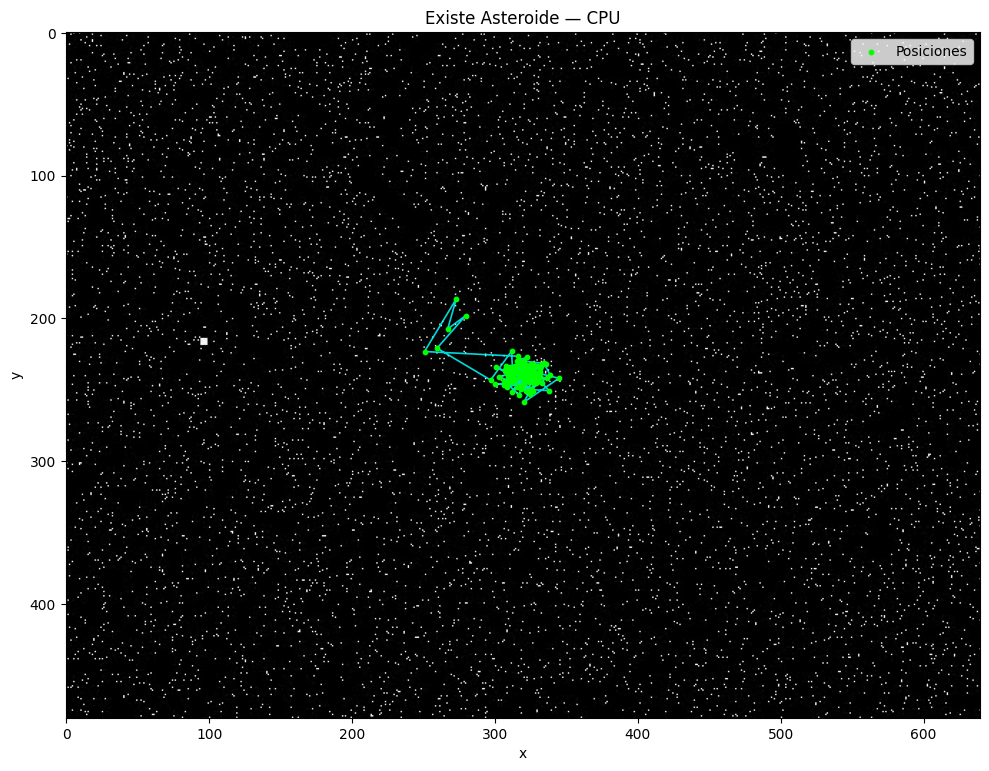

[CUDA] Existe Asteroide
[CUDA] frames: 120 puntos: 119 tiempo_s: 0.9073
[Acel. aprox.] CPU/CUDA: 7.75 ×


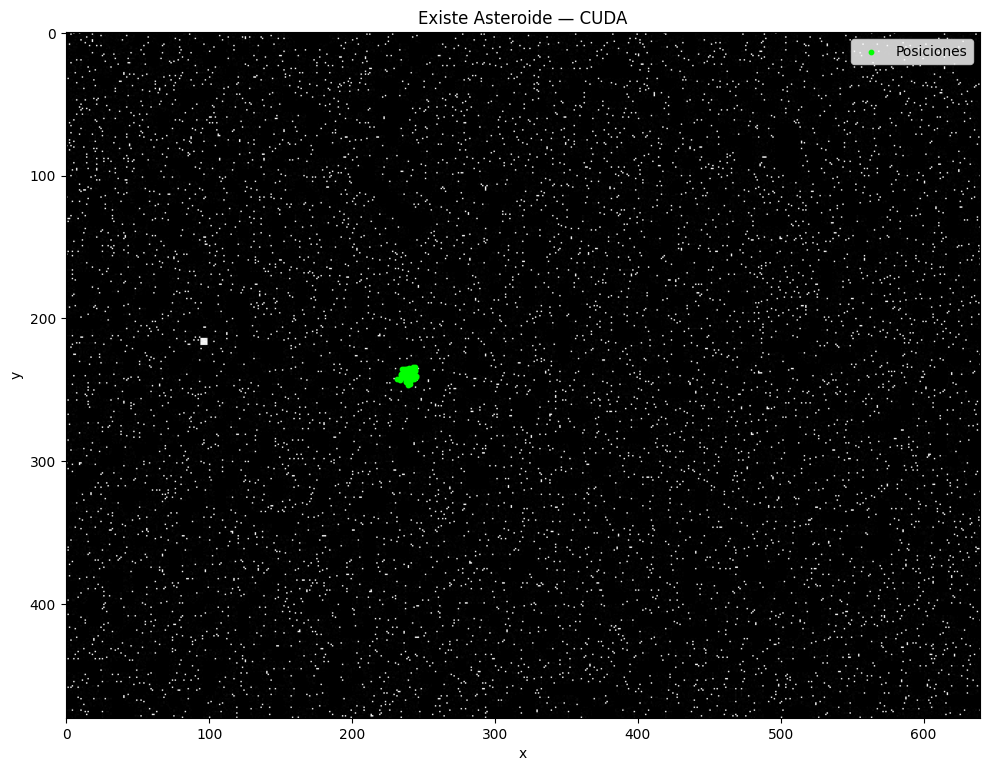

In [9]:
def plot_trayectoria(fondo, trayectoria, titulo: str):
    fig, ax = plt.subplots(figsize=(10, 8))
    ax.imshow(fondo, cmap="gray", aspect="equal")
    if trayectoria:
        xs = [p[0] for p in trayectoria]
        ys = [p[1] for p in trayectoria]
        ax.scatter(xs, ys, c="lime", s=10, label="Posiciones", zorder=5)
        if len(trayectoria) > 1:
            ax.plot(xs, ys, color="cyan", linewidth=1.2, alpha=0.85, zorder=4)
        ax.legend(loc="upper right")
    ax.set_title(titulo)
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    plt.tight_layout()
    plt.show()


tr_cpu, fondo_cpu, t_cpu, nfr_cpu = ejecutar_cpu(VIDEO_PATH, UMBRAL, MAX_FRAMES)
ver_cpu = "Existe Asteroide" if tr_cpu else "No Existe Asteroide"
print("[CPU]", ver_cpu)
print("[CPU] frames:", nfr_cpu, "puntos:", len(tr_cpu), "tiempo_s:", round(t_cpu, 4))
plot_trayectoria(fondo_cpu, tr_cpu, f"{ver_cpu} — CPU")

if gpu_disponible():
    tr_g, fondo_g, t_g, nfr_g = ejecutar_cuda(VIDEO_PATH, UMBRAL, MAX_FRAMES)
    ver_g = "Existe Asteroide" if tr_g else "No Existe Asteroide"
    print("[CUDA]", ver_g)
    print("[CUDA] frames:", nfr_g, "puntos:", len(tr_g), "tiempo_s:", round(t_g, 4))
    if nfr_cpu > 1 and t_cpu > 0 and t_g > 0:
        print("[Acel. aprox.] CPU/CUDA:", round(t_cpu / t_g, 2), "×")
    plot_trayectoria(fondo_g, tr_g, f"{ver_g} — CUDA")
else:
    print("Omitido CUDA: asigna GPU en Colab o instala drivers Numba/CUDA.")


### Datos para el informe

Copia a tu informe: veredictos, tiempos, capturas de las figuras y mención del hardware (`!nvidia-smi` en una celda nueva). Versiones de software:

In [10]:
import sys
print("Python:", sys.version)
print("OpenCV:", cv2.__version__)
print("NumPy:", np.__version__)
import matplotlib
print("Matplotlib:", matplotlib.__version__)
import numba
print("Numba:", numba.__version__)
import shutil
import subprocess
if shutil.which("nvidia-smi"):
    subprocess.run(["nvidia-smi"], check=False)
else:
    print("nvidia-smi no disponible (sesión solo CPU)")


Python: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
OpenCV: 4.13.0
NumPy: 2.0.2
Matplotlib: 3.10.0
Numba: 0.60.0
